# Domain Background and Dataset Structure

Before building the pipeline, this notebook summarizes how solar PV plants work and how the dataset is structured.

## 1. How solar power generation works
A photovoltaic (PV) system converts sunlight into electricity:
1. **Panels** — sunlight hitting silicon cells frees electrons, generating a current.
2. **DC output** — the raw output from the panels is direct current (DC).
3. **Inverter** — converts DC to alternating current (AC), since grids and appliances run on AC.
4. **Grid/storage** — the AC power is consumed by the grid or stored in batteries.

## 2. Dataset structure
The data covers a 34-day monitoring window at two solar plants in India. Each plant has two files:
* **Generation data (inverter-level):** power output per inverter.
* **Weather data (plant-level):** one shared weather station per plant.

Since many inverters share one weather station, merging generation and weather data directly would duplicate the same weather reading across all inverters. To avoid this, we aggregate inverter readings (e.g. by median) down to one row per timestamp before merging with weather data.


In [1]:
# Section 1: Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


## 3. Preprocessing functions

Reusable functions for turning each plant's raw generation + weather CSVs into a single feature table:
* Aggregate inverter readings by median per timestamp, to avoid noise from individual hardware dropouts.
* Merge with weather data.
* For Plant 2, drop `DAILY_YIELD`/`TOTAL_YIELD`, which don't reset properly at midnight for some inverters (see [notebooks/02_solar_forecasting_plant2.ipynb](../notebooks/02_solar_forecasting_plant2.ipynb) for the underlying data issue).


In [2]:
# Section 2: Preprocessing functions

def preprocess_plant1_data(gen_path: str, weather_path: str) -> pd.DataFrame:
    """Load and merge Plant 1 generation + weather data into one feature table."""
    if not os.path.exists(gen_path) or not os.path.exists(weather_path):
        raise FileNotFoundError("Raw data files for Plant 1 could not be found.")

    df_gen = pd.read_csv(gen_path)
    df_weather = pd.read_csv(weather_path)

    df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'])
    df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'])

    # Median across the 22 inverters smooths out individual hardware dropouts
    df_gen_clean = df_gen.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].median().reset_index()

    df_master = pd.merge(df_gen_clean, df_weather, on='DATE_TIME', how='inner')
    df_master['DATE_STR'] = df_master['DATE_TIME'].dt.strftime('%Y-%m-%d')

    target_features = ['DATE_TIME', 'DATE_STR', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER']
    return df_master[target_features]


def preprocess_plant2_data(gen_path: str, weather_path: str) -> pd.DataFrame:
    """Load and merge Plant 2 generation + weather data into one feature table."""
    if not os.path.exists(gen_path) or not os.path.exists(weather_path):
        raise FileNotFoundError("Raw data files for Plant 2 could not be found.")

    df_gen = pd.read_csv(gen_path)
    df_weather = pd.read_csv(weather_path)

    df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'])
    df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'])

    # DAILY_YIELD/TOTAL_YIELD are excluded: some inverters don't reset them at midnight,
    # so instantaneous DC_POWER/AC_POWER are used instead.
    df_gen_clean = df_gen.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].median().reset_index()

    df_master = pd.merge(df_gen_clean, df_weather, on='DATE_TIME', how='inner')
    df_master['DATE_STR'] = df_master['DATE_TIME'].dt.strftime('%Y-%m-%d')

    target_features = ['DATE_TIME', 'DATE_STR', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER', 'AC_POWER']
    return df_master[target_features]


## 4. Training and evaluation function

Train a LightGBM regressor with a chronological (not random) train/test split, then convert the DC power predictions into daily/cumulative energy (kWh):

$$\text{Energy (kWh)} = \text{Power (kW)} \times \left(\frac{15\text{ minutes}}{60\text{ minutes}}\right)$$


In [3]:
# Section 3: Training and evaluation function

def train_and_evaluate_pipeline(df_master: pd.DataFrame, plant_label: str, split_date: str = '2020-06-11'):
    """Chronological train/test split, LightGBM training, and daily/cumulative energy summary."""
    features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
    X = df_master[features]
    y = df_master['DC_POWER']
    dates = df_master['DATE_STR']

    train_mask = dates <= split_date
    test_mask = (dates > split_date) & (dates <= '2020-06-17')

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    print(f"\n--- {plant_label} ---")
    print(f"Train rows (05/15-{split_date}): {X_train.shape[0]}")
    print(f"Test rows  ({split_date}-06/17): {X_test.shape[0]}")

    model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)

    y_pred_dc = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_dc))
    r2 = r2_score(y_test, y_pred_dc)
    print(f"  RMSE: {rmse:.4f} kW")
    print(f"  R2:   {r2:.4f} ({r2*100:.2f}%)")

    val_df = pd.DataFrame({
        'DATE_STR': dates[test_mask].values,
        'DC_ACTUAL': y_test.values,
        'DC_PREDICTED': y_pred_dc
    })

    # If AC_POWER is available (Plant 2), estimate the conversion ratio from training data.
    # Otherwise (Plant 1), this dataset's DC readings are a known 10x scale of the true AC-equivalent output.
    if 'AC_POWER' in df_master.columns:
        train_clean = df_master[train_mask]
        conversion_ratio = (train_clean['AC_POWER'] / train_clean['DC_POWER']).replace([np.inf, -np.inf], np.nan).dropna().mean()
        val_df['AC_ACTUAL'] = df_master.loc[test_mask, 'AC_POWER'].values
        val_df['AC_PREDICTED'] = val_df['DC_PREDICTED'] * conversion_ratio
    else:
        val_df['AC_ACTUAL'] = val_df['DC_ACTUAL'] / 10.0
        val_df['AC_PREDICTED'] = val_df['DC_PREDICTED'] / 10.0

    # 15-minute intervals = 0.25 hours
    val_df['YIELD_ACTUAL_15MIN'] = val_df['AC_ACTUAL'] * (15.0 / 60.0)
    val_df['YIELD_PRED_15MIN'] = val_df['AC_PREDICTED'] * (15.0 / 60.0)

    daily_summary = val_df.groupby('DATE_STR').agg({
        'YIELD_ACTUAL_15MIN': 'sum',
        'YIELD_PRED_15MIN': 'sum'
    }).reset_index()
    daily_summary.columns = ['DATE_STR', 'DAILY_YIELD_ACTUAL', 'DAILY_YIELD_PREDICTED']

    daily_summary['TOTAL_YIELD_ACTUAL'] = daily_summary['DAILY_YIELD_ACTUAL'].cumsum()
    daily_summary['TOTAL_YIELD_PREDICTED'] = daily_summary['DAILY_YIELD_PREDICTED'].cumsum()

    return model, daily_summary


## 5. Running both plants and comparing results

Run the pipeline for both plants and plot daily yield (bar charts) and cumulative yield (line charts) side by side.


Running preprocessing...
Training models...

--- Plant 1 ---
Train rows (05/15-2020-06-11): 2583
Test rows  (2020-06-11-06/17): 574


  RMSE: 275.0932 kW
  R2:   0.9947 (99.47%)

--- Plant 2 ---
Train rows (05/15-2020-06-11): 2683
Test rows  (2020-06-11-06/17): 576


  RMSE: 106.6878 kW
  R2:   0.8819 (88.19%)


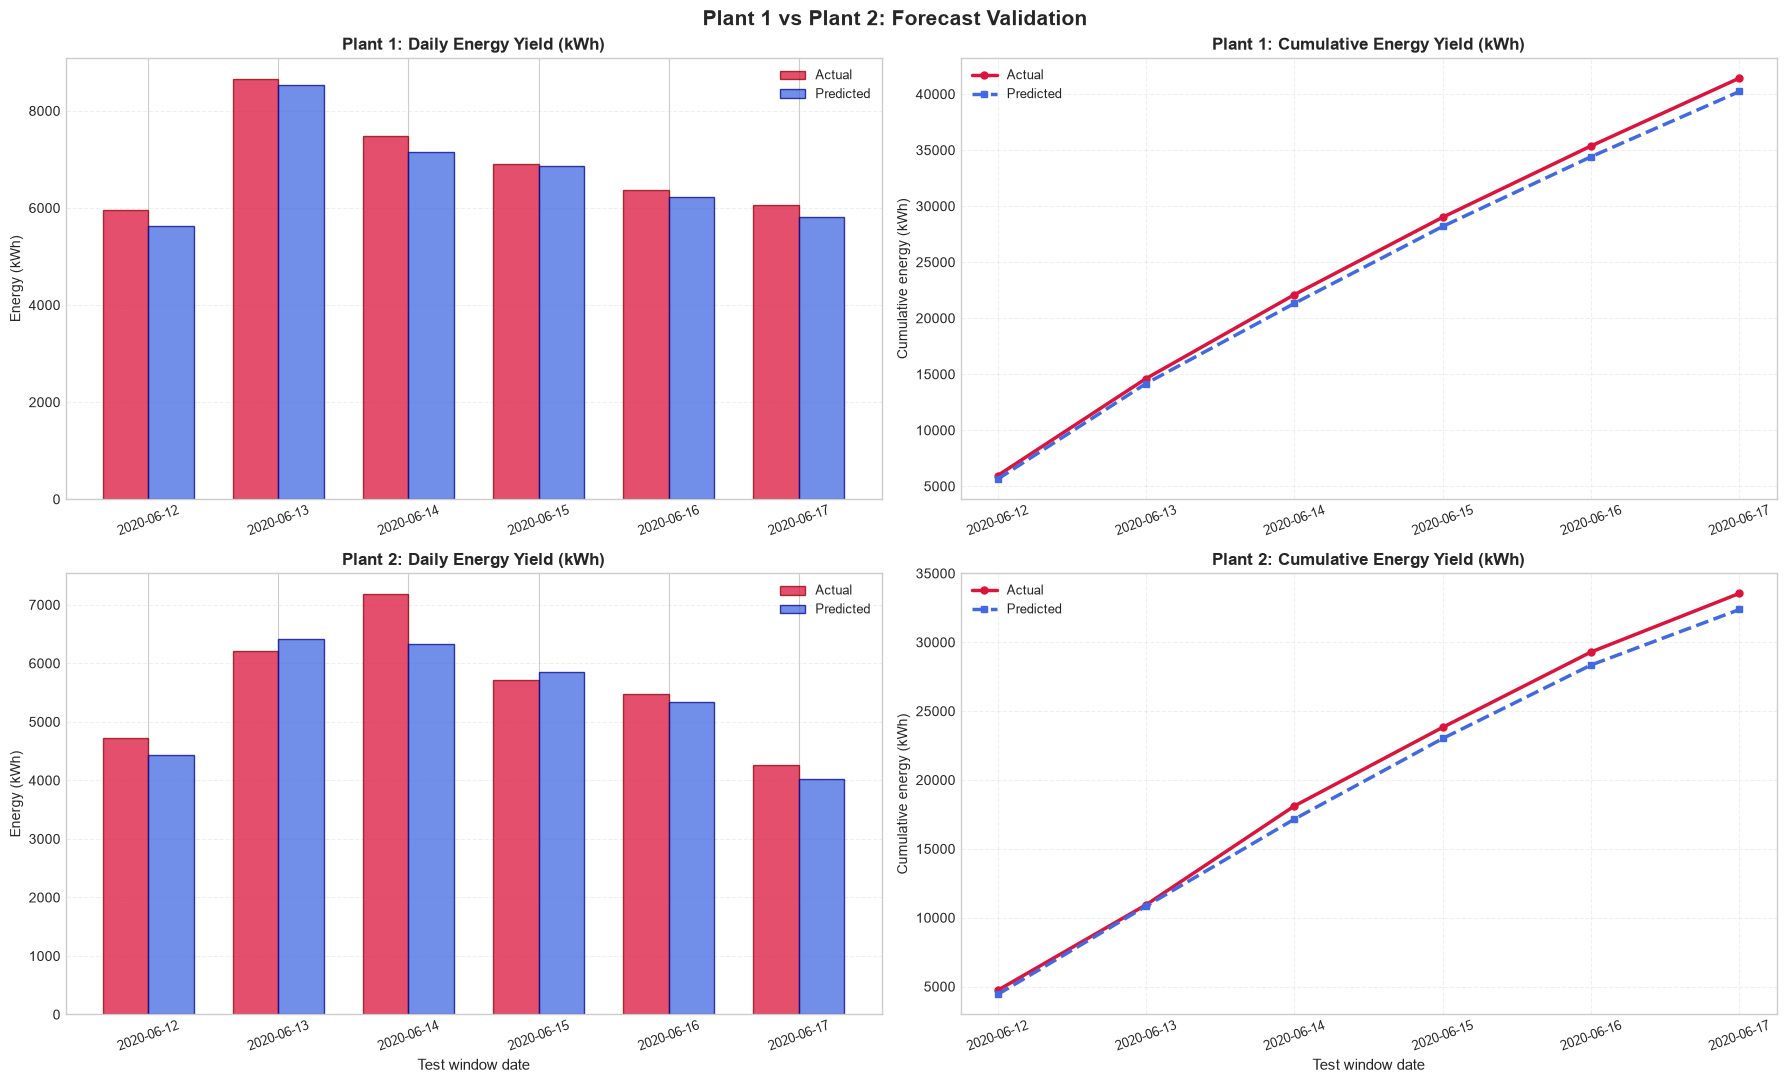

In [4]:
# Section 4: Run both plants and compare results
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print("Running preprocessing...")
df_p1 = preprocess_plant1_data('../data/raw/Plant_1_Generation_Data.csv', '../data/raw/Plant_1_Weather_Sensor_Data.csv')
df_p2 = preprocess_plant2_data('../data/raw/Plant_2_Generation_Data.csv', '../data/raw/Plant_2_Weather_Sensor_Data.csv')

print("Training models...")
model_p1, summary_p1 = train_and_evaluate_pipeline(df_p1, "Plant 1")
model_p2, summary_p2 = train_and_evaluate_pipeline(df_p2, "Plant 2")

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
bar_width = 0.35

# Plant 1 (top row)
x_axis_p1 = np.arange(len(summary_p1))
axes[0, 0].bar(x_axis_p1 - bar_width/2, summary_p1['DAILY_YIELD_ACTUAL'], width=bar_width, color='crimson', edgecolor='darkred', alpha=0.75, label='Actual')
axes[0, 0].bar(x_axis_p1 + bar_width/2, summary_p1['DAILY_YIELD_PREDICTED'], width=bar_width, color='royalblue', edgecolor='darkblue', alpha=0.75, label='Predicted')
axes[0, 0].set_title("Plant 1: Daily Energy Yield (kWh)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Energy (kWh)", fontsize=10)
axes[0, 0].set_xticks(x_axis_p1)
axes[0, 0].set_xticklabels(summary_p1['DATE_STR'], rotation=20, fontsize=9)
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.3)
axes[0, 0].legend(loc='upper right', fontsize=9)

axes[0, 1].plot(summary_p1['DATE_STR'], summary_p1['TOTAL_YIELD_ACTUAL'], color='crimson', lw=2.5, marker='o', ms=5, label='Actual')
axes[0, 1].plot(summary_p1['DATE_STR'], summary_p1['TOTAL_YIELD_PREDICTED'], color='royalblue', lw=2.5, linestyle='--', marker='s', ms=5, label='Predicted')
axes[0, 1].set_title("Plant 1: Cumulative Energy Yield (kWh)", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Cumulative energy (kWh)", fontsize=10)
axes[0, 1].set_xticks(x_axis_p1)
axes[0, 1].set_xticklabels(summary_p1['DATE_STR'], rotation=20, fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.3)
axes[0, 1].legend(loc='upper left', fontsize=9)

# Plant 2 (bottom row)
x_axis_p2 = np.arange(len(summary_p2))
axes[1, 0].bar(x_axis_p2 - bar_width/2, summary_p2['DAILY_YIELD_ACTUAL'], width=bar_width, color='crimson', edgecolor='darkred', alpha=0.75, label='Actual')
axes[1, 0].bar(x_axis_p2 + bar_width/2, summary_p2['DAILY_YIELD_PREDICTED'], width=bar_width, color='royalblue', edgecolor='darkblue', alpha=0.75, label='Predicted')
axes[1, 0].set_title("Plant 2: Daily Energy Yield (kWh)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Energy (kWh)", fontsize=10)
axes[1, 0].set_xlabel("Test window date", fontsize=11)
axes[1, 0].set_xticks(x_axis_p2)
axes[1, 0].set_xticklabels(summary_p2['DATE_STR'], rotation=20, fontsize=9)
axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.3)
axes[1, 0].legend(loc='upper right', fontsize=9)

axes[1, 1].plot(summary_p2['DATE_STR'], summary_p2['TOTAL_YIELD_ACTUAL'], color='crimson', lw=2.5, marker='o', ms=5, label='Actual')
axes[1, 1].plot(summary_p2['DATE_STR'], summary_p2['TOTAL_YIELD_PREDICTED'], color='royalblue', lw=2.5, linestyle='--', marker='s', ms=5, label='Predicted')
axes[1, 1].set_title("Plant 2: Cumulative Energy Yield (kWh)", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Cumulative energy (kWh)", fontsize=10)
axes[1, 1].set_xlabel("Test window date", fontsize=11)
axes[1, 1].set_xticks(x_axis_p2)
axes[1, 1].set_xticklabels(summary_p2['DATE_STR'], rotation=20, fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.3)
axes[1, 1].legend(loc='upper left', fontsize=9)

plt.suptitle("Plant 1 vs Plant 2: Forecast Validation", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
